# Project 5 - Analysis of Water Quality Along the McClusky Canal 
**Client:** Garrison Diversion Project & Red River Valley Water Supply Project  

---

In [26]:
#Importing the packages needed to complete the project

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


In [27]:
#Loading the water quality dataset and locations of interest

water_data = pd.read_csv("Green_CIVE202_Project5_RRVWSP(in).csv", low_memory = False)
locations = pd.read_csv("List of USGS Canal Locations(Sheet1).csv")

#Changing results so that they are all numberic

water_data["ResultMeasureValue"] = pd.to_numeric(water_data["ResultMeasureValue"])

#Changing the date column so that it can be used later if needed

water_data["ActivityStartDate"] = pd.to_datetime(water_data["ActivityStartDate"])

In [28]:
#Define the locations that we are focusing on in the canal and the river

canal_locations = ["Lake Sakakawea", "Lake Audubon - Deepest", "New Johns Lake - Deepest", "West Park Lake - Deepest",
                   "East Park Lake - Deepest", "Heckers Lake - Deepest", "Lake Ashtabula"]

sheyenne_locations = ["Sheyenne River - Warwick", "Sheyenne River Nr Maddock, ND", "Sheyenne River Nr Harvey, ND",
                      "Sheyenne River In Lisbon ND", "Sheyenne River - Lisbon", "Sheyenne River SE of Kindred"]

#Define the water quality parameters of interest

params = { 
    "Cations": ["Calcium", "Magnesium", "Sodium", "Sodium adsorption ration [(NA)/(sq root of 1/2 Ca + Mg)]"],
    "Anions": ["Chloride", "Sulfate", "Carbonate", "Bicarbonate"],
    "Other": ["Total dissolved solids", "pH", "Hardess, carbonate"]}

all_params = params

flat_params = [p for group in params.values() for p in group]

In [44]:
#Cleaning and filtering so that I keep only the locations I need

canal_water_data = water_data[(water_data["location_name"].isin(canal_locations)) & (water_data["CharacteristicName"].isin(flat_params))].copy()

#Ordering so that the plots stay consistent

canal_water_data["location_name"] = pd.Categorical(canal_water_data["location_name"], categories = canal_locations, ordered = True)

In [47]:
#Create a function to calculate basic stats for each parameter and location

def summary(df, param, locations):
    data = df[df["CharacteristicName"] == param].dropna(subset = ["ResultMeasureValue"])

    results = []

    for loc in locations:
        vals = data[data["location_name"] == loc]["ResultMeasureValue"]

        results.append([loc, vals.mean(), vals.median(), vals.max(), vals.min(), len(vals)])

    return pd.DataFrame(results, columns = ["Location", "Mean", "Median", "Max", "Min", "n"])

    #results, columns = ["Location", "Mean", "Median", "Max", "Min", "n"]

In [49]:
#Print the summary tables with stats for the parameters
#title for the output
print("=" * 70)
print("Summary Statistics - Canal Locations (mg/L)")
print("="*70)
#code to print the data from the previous function
for group, params in all_params.items():
    print(f"\n{'-'*70}")
    print(f"  {group.upper()}")
    print(f"{'-'*70}")
    for param in params:
        table = summary(canal_water_data, param, canal_locations)
        label = all_params.get(param, param)
        print(f"\n {label}")
        print(table.to_string(index=False))

Summary Statistics - Canal Locations (mg/L)

----------------------------------------------------------------------
  CATIONS
----------------------------------------------------------------------

 Calcium
                Location      Mean  Median   Max  Min   n
          Lake Sakakawea 49.452564    49.5  56.1 41.0  78
  Lake Audubon - Deepest 41.975000    42.1  43.7 40.0   4
New Johns Lake - Deepest 82.700000    81.2  93.3 73.4   7
West Park Lake - Deepest 49.000000    48.9  55.1 44.9   7
East Park Lake - Deepest 57.800000    56.6  67.4 49.1   7
  Heckers Lake - Deepest 70.557143    70.1  81.8 64.2   7
          Lake Ashtabula 74.736301    75.7 128.0 48.8 292

 Magnesium
                Location       Mean  Median   Max  Min   n
          Lake Sakakawea  19.893590   19.70  25.6 17.5  78
  Lake Audubon - Deepest  37.025000   35.80  41.2 35.3   4
New Johns Lake - Deepest 103.657143  105.00 114.0 92.6   7
West Park Lake - Deepest  53.314286   52.80  58.4 48.3   7
East Park Lake - Deepe

**Plotting boxplots for parameters and TDS means along the canal**

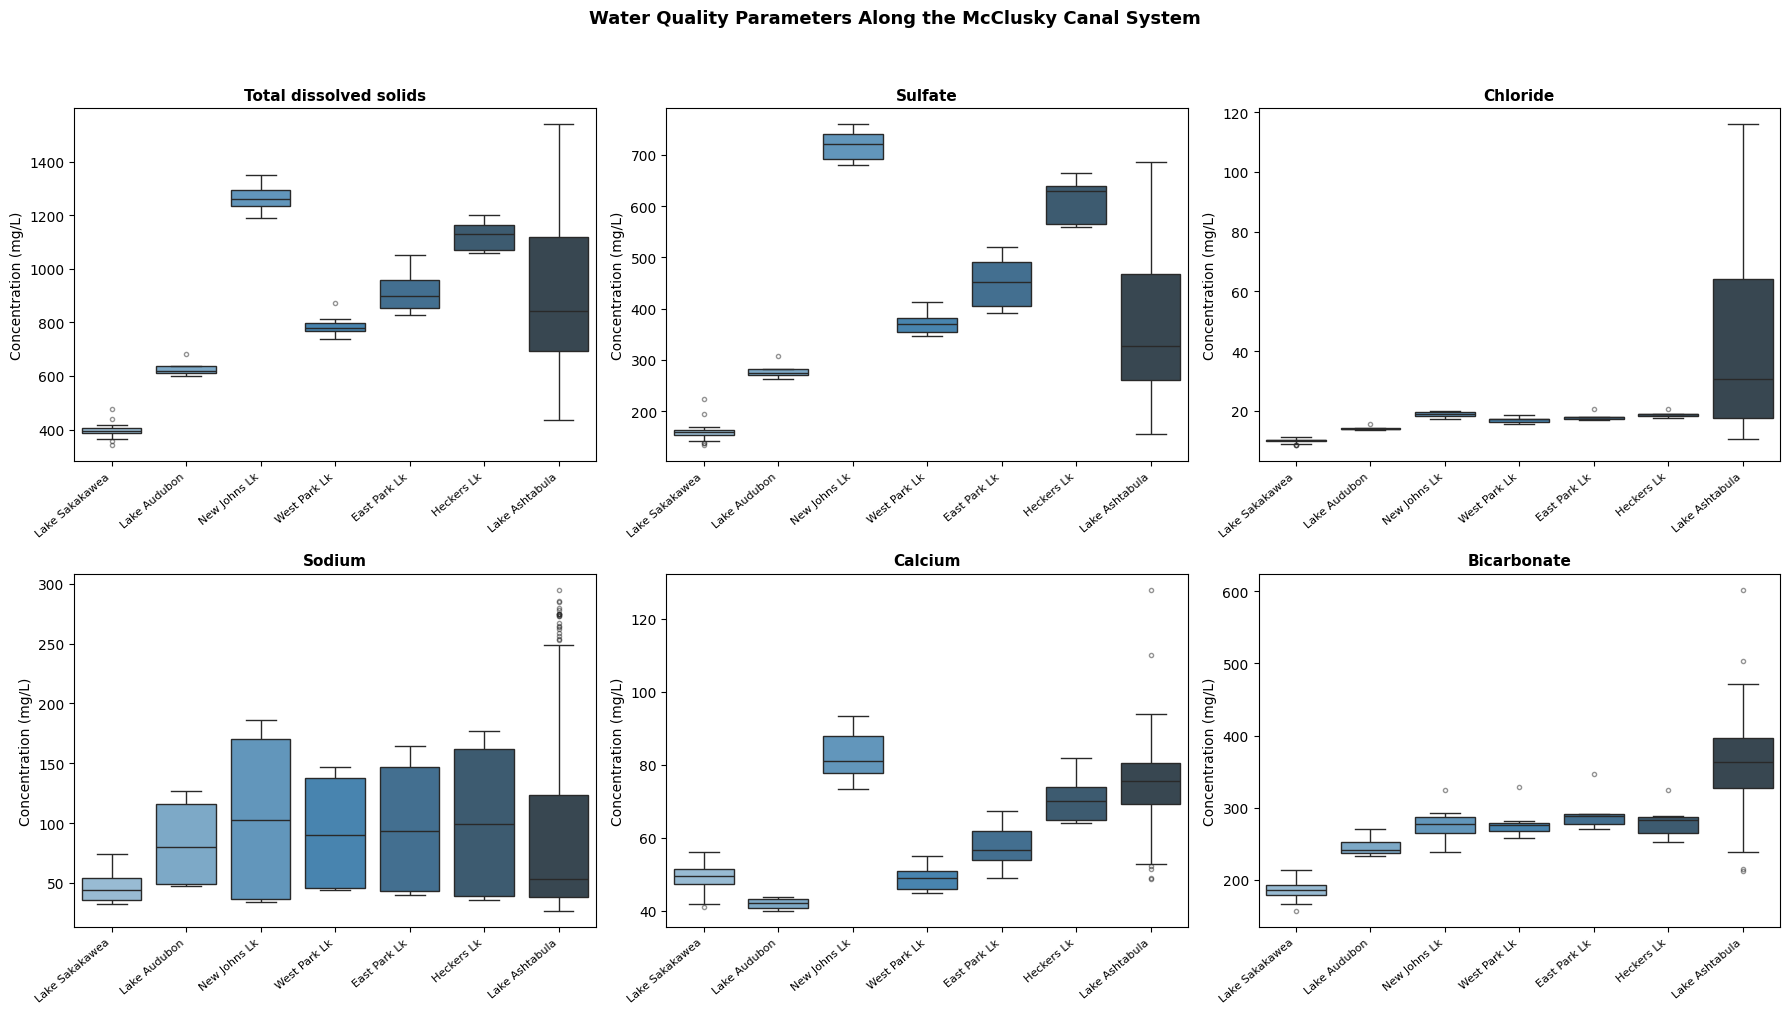

In [59]:
#The next step is to create the boxplots
#We are choosing to plot boxplots for 6 parameters: TDS, Sulfate, Chloride, Sodium, Calcium, and Bicarbonate
boxplot_params = ["Total dissolved solids", "Sulfate", "Chloride", "Sodium", "Calcium", "Bicarbonate"]

short_labels = [loc.replace(" - Deepest", "").replace(" Lake", " Lk")
                for loc in canal_locations]

fig, axes = plt.subplots(2, 3, figsize = (18,10))
axes = axes.flatten()

for i, param in enumerate(boxplot_params):
    ax = axes[i]
    subset = canal_water_data[canal_water_data["CharacteristicName"] == param].dropna(subset=["ResultMeasureValue"])

    sns.boxplot(data = subset, x = "location_name", y = "ResultMeasureValue", hue = "location_name", palette = "Blues_d",
            order = canal_locations, ax = ax, flierprops = dict(marker = "o", markersize = 3, alpha = 0.5))
    ax.set_title(all_params.get(param, param), fontsize = 11, fontweight = "bold")
    ax.set_xlabel("")
    ax.set_ylabel("Concentration (mg/L)" if param != "pH" else "pH units")
    ax.set_xticks(range(len(short_labels)))
    ax.set_xticklabels(short_labels, rotation = 40, ha= "right", fontsize = 8)

fig.suptitle("Water Quality Parameters Along the McClusky Canal System\n", fontsize = 13, fontweight = "bold", y=1.01)
plt.tight_layout()
plt.show()

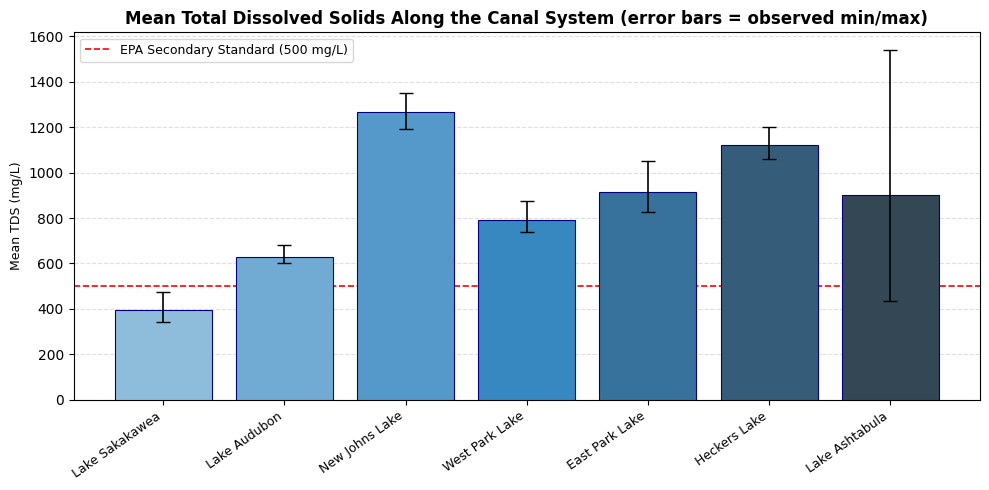

In [63]:
#Creating a bar chart of mean TDS along the canal

tds_summary = summary(canal_water_data, "Total dissolved solids", canal_locations)
tds_summary = tds_summary[tds_summary["n"] > 0]

fig, ax = plt.subplots(figsize = (10,5))
bars = ax.bar(range(len(tds_summary)), tds_summary["Mean"], color = sns.color_palette("Blues_d", len(tds_summary)),
              edgecolor = "navy", linewidth = 0.8, zorder = 3)
ax.errorbar(range(len(tds_summary)), tds_summary["Mean"],
            yerr = [tds_summary["Mean"] - tds_summary["Min"], tds_summary["Max"] - tds_summary["Mean"]],
            fmt = "none", color = "black", capsize = 5, linewidth = 1.2, zorder = 4)
ax.set_xticks(range(len(tds_summary)))
ax.set_xticklabels([l.replace(" - Deepest", "").replace(" Lake", " Lake") for l in tds_summary["Location"]],
                   rotation = 35, ha = "right", fontsize = 9)
ax.set_ylabel("Mean TDS (mg/L)", fontsize = 9)
ax.set_title("Mean Total Dissolved Solids Along the Canal System (error bars = observed min/max)",
             fontsize = 12, fontweight = "bold")
ax.axhline(500, color = "red", linestyle = "--", linewidth = 1.2, label = "EPA Secondary Standard (500 mg/L)")
ax.legend(fontsize = 9)
ax.grid(axis = "y", linestyle = "--", alpha = 0.4, zorder = 0)
plt.tight_layout()
plt.show()

**Creating a function for the mass balance equation**

In [64]:
#this cell defines the function for mass balance based on what the client provided

def tds_mass_balance(Q_pipe_cfs, C_pipe_mgL, Q_sheyenne_cfs, C_sheyenne_mgL):
    
    #This will compute the mixed TDS concentration in Lake Ashtabula after the pipe discharges into the river

    Q_total = Q_pipe_cfs + Q_sheyenne_cfs
    C_mixed = (Q_pipe_cfs * C_pipe_mgL + Q_sheyenne_cfs * C_sheyenne_mgL) / Q_total

    return {"Q_pipe_cfs":        Q_pipe_cfs,
            "C_pipe_mgL":        C_pipe_mgL,
            "Q_sheyenne_cfs":    Q_sheyenne_cfs,
            "Q_ashtabula_cfs":   round(Q_total, 3),
            "C_ashtabula_mgL":  round(C_mixed, 3)}

In [75]:
sakakawea_tds = canal_water_data[
    (canal_water_data["location_name"] == "Lake Sakakawea") &
    (canal_water_data["CharacteristicName"] == "Total dissolved solids")]["ResultMeasureValue"].dropna()

sheyenne_water_data = water_data[water_data["location_name"].isin(sheyenne_locations)
    & (water_data["CharacteristicName"] == "Total dissolved solids")]

sheyenne_tds = pd.to_numeric(sheyenne_water_data["ResultMeasureValue"], errors = "coerce").dropna()

#Used 50 cfs as a representative for now, the number can be changed to look at different scenarios

Q_sheyenne = 50.0 #cfs
Q_pipe_design = 6.0 #cfs - specified design flow
C_pipe_median = round(sakakawea_tds.median(), 1)
C_sheyenne_median = round(sheyenne_tds.median(), 1)

print("\n" + "=" * 70)
print("Mass Balance - TDS in Lake Ashtabula")
print("=" * 70)
print(f" Pipeline TDS (median Lake Sakakawea): {C_pipe_median} mg/L (n = {len(sakakawea_tds)})")
print(f" Sheyenne TDS (median Sheyenne River): {C_sheyenne_median} mg/L (n = {len(sheyenne_tds)})")
print(f" Q_pipe (design):                      {Q_pipe_design} cfs")
print(f" Q_Sheyenne (approximate low-flow):    {Q_sheyenne} cfs")

baseline = tds_mass_balance(Q_pipe_design, C_pipe_median, Q_sheyenne, C_sheyenne_median)

print(f"\n Baseline Mixed TDS in Lake Ashtabula: {baseline['C_ashtabula_mgL']} mg/L")
print(f" Total Flow into Lake Ashtabula:       {baseline['Q_ashtabula_cfs']} cfs")


Mass Balance - TDS in Lake Ashtabula
 Pipeline TDS (median Lake Sakakawea): 394.5 mg/L (n = 78)
 Sheyenne TDS (median Sheyenne River): 809.0 mg/L (n = 196)
 Q_pipe (design):                      6.0 cfs
 Q_Sheyenne (approximate low-flow):    50.0 cfs

 Baseline Mixed TDS in Lake Ashtabula: 764.589 mg/L
 Total Flow into Lake Ashtabula:       56.0 cfs


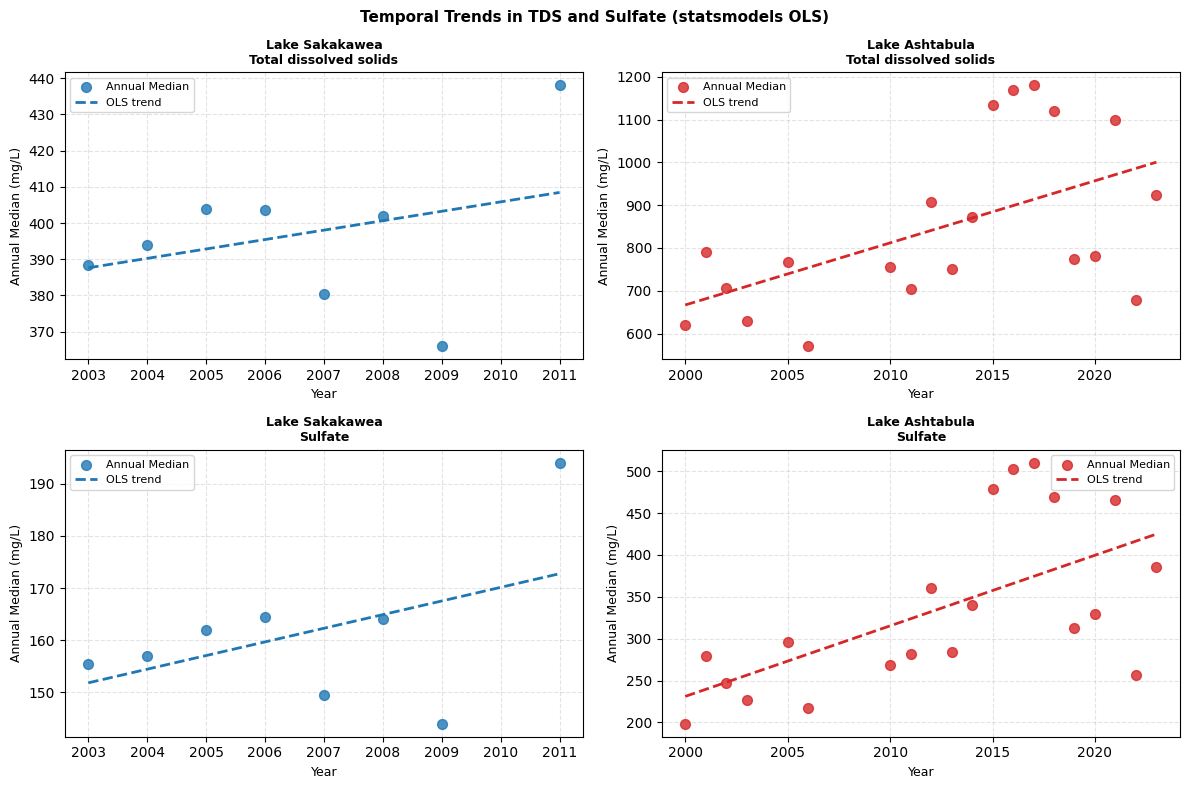

In [80]:
#Doing a trend analysis by creating a graph and using statsmodels OLS

trend_locations = ["Lake Sakakawea", "Lake Ashtabula"]
trend_params = ["Total dissolved solids", "Sulfate"]
trend_colors = {"Lake Sakakawea": "#1f77b4", "Lake Ashtabula": "#d62728"}

fig, axes = plt.subplots(len(trend_params), len(trend_locations), figsize = (12,8), sharey = False)

for row_i, param in enumerate(trend_params):
    for col_i, loc in enumerate(trend_locations):
        ax = axes[row_i][col_i]
        color = trend_colors[loc]

        subset = (water_data[(water_data["location_name"] == loc) & (water_data["CharacteristicName"] == param)]
            .dropna(subset = ["ResultMeasureValue", "year"]).copy())
        subset["year"] = subset["year"].astype(float)

        annual = subset.groupby("year")["ResultMeasureValue"].median().reset_index()
        annual.columns = ["year", "value"]

        X = sm.add_constant(annual["year"])
        y = annual["value"]
        model = sm.OLS(y, X).fit()

        slope = model.params["year"]
        intercept = model.params["const"]
        pval = model.pvalues["year"]
        r2 = model.rsquared

        ax.scatter(annual["year"], annual["value"], color = color, s = 50, zorder = 4, alpha = 0.8, label = "Annual Median")
        x_line = [annual["year"].min(), annual["year"].max()]
        y_line = [intercept + slope *x for x in x_line]
        ax.plot(x_line, y_line, color = color, linewidth = 2, linestyle = "--", label = f"OLS trend")

        label = all_params.get(param, param)
        ax.set_title(f"{loc}\n{label}", fontsize = 9, fontweight = "bold")
        ax.set_xlabel("Year", fontsize = 9)
        ax.set_ylabel("Annual Median (mg/L)", fontsize = 9)
        ax.legend(fontsize = 8)
        ax.grid(linestyle = "--", alpha = 0.35)

fig.suptitle("Temporal Trends in TDS and Sulfate (statsmodels OLS)", fontsize = 11, fontweight = "bold")
plt.tight_layout()
plt.show()